# Limits and Convergence of Algorithms

In [3]:
import numpy as np
import matplotlib.pyplot as plt

---
## 1. Review: polynomial vs. exponential growth

| | polynomial $t \approx c\,n^a$ | exponential $t \approx c\,b^{\,n}$ ($b > 1$) |
|---|---|---|
| typical code | $a$ nested loops | try every subset ($b = 2$) |
| take logs | $\log t \approx a \log n + \log c$ | $\log t \approx n \log b + \log c$ |
| straight line on | `loglog` | `semilogy` |
| slope | $a$ (the exponent) | $\log b$, so $b = e^{\text{slope}}$ |

Run the cell and look for the straight lines.

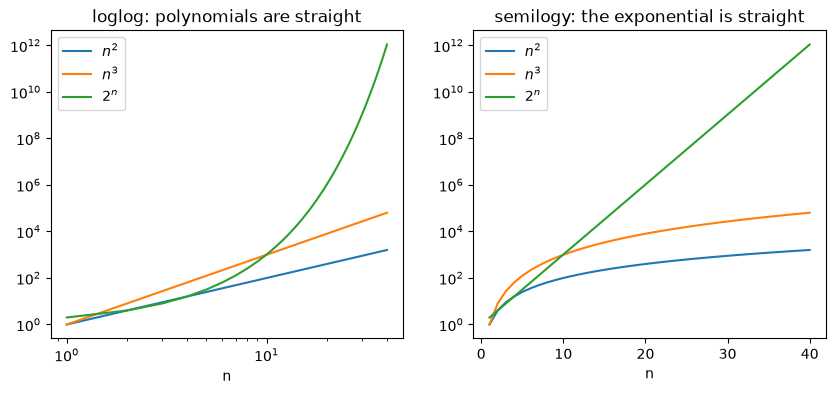

In [4]:
n = np.arange(1, 41)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax in axes:
    ax.plot(n, n**2, label="$n^2$")
    ax.plot(n, n**3, label="$n^3$")
    ax.plot(n, 2.0**n, label="$2^n$")
    ax.set_xlabel("n")
    ax.legend()
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_title("loglog: polynomials are straight")
axes[1].set_yscale("log");                              axes[1].set_title("semilogy: the exponential is straight")
plt.show()

To **estimate** the parameter, fit a line with `np.polyfit`:

```python
a = np.polyfit(np.log(ns), np.log(ts), 1)[0]        # polynomial model: slope = a
b = np.exp(np.polyfit(ns, np.log(ts), 1)[0])        # exponential model: b = e^slope
```

`polyfit` **always** returns a number, even for the wrong model. **The split test:** fit the first half and the second half of the data separately. With the right model both halves agree; with the wrong model the value drifts.

---
## 2. Limits of sequences

A **sequence** is a list of numbers $x_0, x_1, x_2, \ldots$ indexed by $k$.

**Definition.** $x_k \to x_\ast$ if for every tolerance $\tau > 0$ there is a $K$ with $|x_k - x_\ast| < \tau$ for all $k \ge K$.

**In words:** choose any tolerance $\tau$, however small. After some index $K$, **every** term stays within $\tau$ of $x_\ast$.

**Example:** $x_k = 1/k \to 0$. For $\tau = 0.01$ we can take $K = 101$. The cell below finds the first $K$ for a few tolerances: a smaller $\tau$ just needs a larger $K$.

In [5]:
k = np.arange(1, 10**6 + 1)
x = 1 / k                                   # the sequence 1/k, limit 0

for tau in [1e-1, 1e-2, 1e-3, 1e-4]:
    K = k[np.abs(x - 0) < tau][0]           # first k with |x_k - 0| < tau
    print(f"tau = {tau:.0e}:  K = {K}")

# two more sequences that converge
x_e = (1 + 1 / k)**k                        # -> e
x_basel = np.cumsum(1 / k**2)               # partial sums -> pi^2 / 6
print("\n(1+1/k)^k  at k = 10^6:", x_e[-1], "   e       =", np.e)
print("sum 1/j^2  at k = 10^6:", x_basel[-1], "   pi^2/6  =", np.pi**2 / 6)

tau = 1e-01:  K = 11
tau = 1e-02:  K = 101
tau = 1e-03:  K = 1001
tau = 1e-04:  K = 10001

(1+1/k)^k  at k = 10^6: 2.7182804690957534    e       = 2.718281828459045
sum 1/j^2  at k = 10^6: 1.64493306684877    pi^2/6  = 1.6449340668482264


---
## 3. Algorithms as sequences

Many algorithms repeat one step, $x_{k+1} = g(x_k)$. Recording the output after every iteration gives a **sequence**.

| algorithm | $g(x)$ |
|---|---|
| Newton for $\sqrt 2$ | $\tfrac12(x + 2/x)$ |
| $\cos$ iteration | $\cos x$ |

**Where can it converge?** If $x_k \to x_\ast$ and $g$ is continuous, taking the limit of $x_{k+1} = g(x_k)$ gives $x_\ast = g(x_\ast)$: the limit is a **fixed point** of $g$.

**Which fixed point does it find?** Near $x_\ast$, one step multiplies the error by about $g'(x_\ast)$:

$$x_{k+1} - x_\ast = g(x_k) - g(x_\ast) \approx g'(x_\ast)\,(x_k - x_\ast).$$

- $|g'(x_\ast)| < 1$: the error shrinks, $x_\ast$ **attracts**, and $C = |g'(x_\ast)|$;
- $|g'(x_\ast)| > 1$: the error grows, $x_\ast$ **repels**.

**Cobweb plot.** The numbers $x_0, x_1, \ldots$ tell you *whether* the iteration settles; the cobweb shows *where* (where $y = g(x)$ crosses $y = x$) and *how* (it spirals in, walks in, or runs away). Each iteration draws **two** segments:

1. **vertical**, from the line to the curve: $(x_k, x_k) \to (x_k, x_{k+1})$;
2. **horizontal**, back to the line: $(x_k, x_{k+1}) \to (x_{k+1}, x_{k+1})$.

Two helpers for the Activity: `iterate` (as you wrote it last time, plus a safety stop when the values blow up) and `cobweb`.

In [6]:
def iterate(g, x0, N, blowup=1e8):
    '''return [x0, x1, ..., xN] with x_{k+1} = g(x_k); stops early if |x| > blowup'''
    xs = [x0]
    for k in range(N):
        xs.append(g(xs[-1]))
        if abs(xs[-1]) > blowup:
            break
    return xs


def cobweb(g, x0, N, xmin, xmax, ax=None):
    '''cobweb plot of N steps of x_{k+1} = g(x_k), starting from x0'''
    if ax is None:
        fig, ax = plt.subplots()
    x = np.linspace(xmin, xmax, 400)
    ax.plot(x, g(x), label="y = g(x)")          # the curve
    ax.plot(x, x, "k", lw=1, label="y = x")     # the line
    xk = x0
    for k in range(N):
        xnew = g(xk)                                     # x_{k+1} = g(x_k)
        ax.plot([xk, xk], [xk, xnew], "r", lw=1)         # vertical: line -> curve
        ax.plot([xk, xnew], [xnew, xnew], "r", lw=1)     # horizontal: curve -> line
        xk = xnew
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_xlabel("$x_k$")
    ax.set_ylabel("$x_{k+1}$")
    ax.legend()
    return ax

**Example.** $g(x) = \cos x$ has one fixed point $x_\ast \approx 0.739$. Since $g'(x) = -\sin x$, we get $|g'(x_\ast)| = \sin(0.739) \approx 0.67 < 1$: it attracts, and the error shrinks by about $0.67$ per step.

$g(x) = x^2$ has two fixed points ($x_\ast^2 = x_\ast$, so $x_\ast = 0$ or $1$). With $g'(x) = 2x$: $g'(0) = 0$ attracts, $g'(1) = 2$ repels.

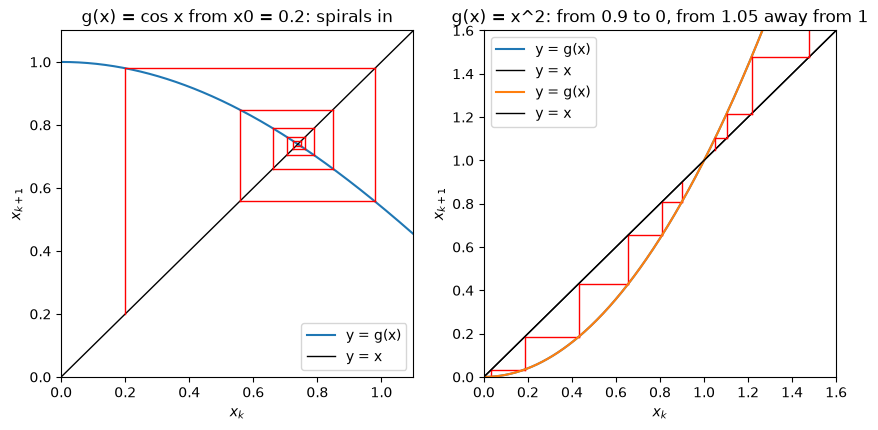

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
cobweb(np.cos, 0.2, 10, 0, 1.1, ax=axes[0])
axes[0].set_title("g(x) = cos x from x0 = 0.2: spirals in")

square = lambda x: x**2
cobweb(square, 0.9, 6, 0, 1.6, ax=axes[1])
cobweb(square, 1.05, 4, 0, 1.6, ax=axes[1])
axes[1].set_title("g(x) = x^2: from 0.9 to 0, from 1.05 away from 1")
plt.show()

---
## 4. Order of convergence

With the error $\epsilon_k = |x_k - x_\ast|$: **how does one iteration shrink the error?**

**Definition.** The convergence has **order** $q \ge 1$ and **rate constant** $C$ if $\displaystyle\lim_{k\to\infty} \frac{\epsilon_{k+1}}{\epsilon_k^{\,q}} = C$ with $0 < C < \infty$. For $q = 1$: $C < 1$ is **linear**, $C = 1$ is **sublinear**.

| name | ratio $\epsilon_{k+1}/\epsilon_k$ | on `semilogy` |
|---|---|---|
| sublinear | **not** constant: creeps up to $1$ (for $1/k$: $\tfrac12, \tfrac23, \tfrac34, \ldots$) | **flattens out** |
| linear | constant $C < 1$ | **straight line**, slope $\log C$ |
| superlinear | goes to $0$ | **bends down** |

### Measuring $q$

1. **Plot $\epsilon_{k+1}$ against $\epsilon_k$ on `loglog` axes.** From $\log \epsilon_{k+1} \approx q \log \epsilon_k + \log C$, the slope is $q$. Sublinear points hug the line $y = x$; linear points run parallel below it; superlinear points are steeper.
2. **Three consecutive errors:** $C$ cancels in
$$q_k = \frac{\log(\epsilon_{k+1}/\epsilon_k)}{\log(\epsilon_k/\epsilon_{k-1})}.$$

**Floating point floor:** use only errors well above $10^{-16}$, for example $\epsilon_k > 10^{-14}$.

### What if $x_\ast$ is not known?

1. **Reference run:** iterate much longer and use the last iterate $x_N$ in place of $x_\ast$. It matches the error, except close to $N$.
2. **Steps** $\delta_k = |x_{k+1} - x_k|$: they run **parallel** to the error, so they give the same $C$ and $q$. But parallel is not equal: for linear convergence the error is about $\frac{C}{1-C}\,\delta_k$, which is large when $C$ is close to $1$.

The cell below shows the three types with model sequences.

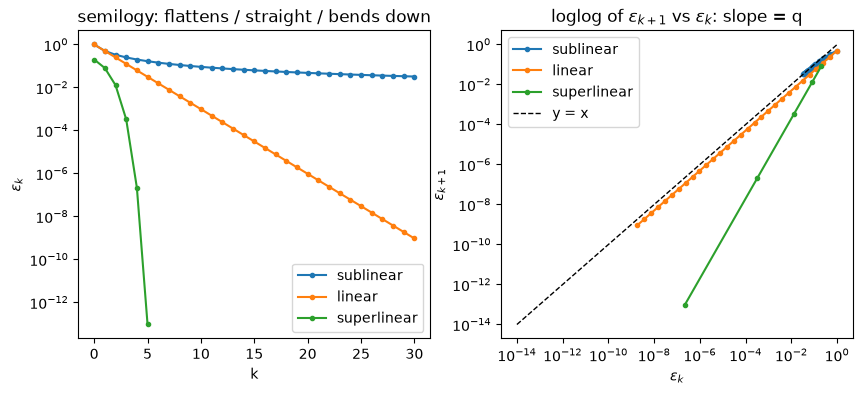

In [8]:
kk = np.arange(0, 31)
e_sub = 1 / (kk + 1)                    # sublinear
e_lin = 0.5**kk                         # linear, C = 0.5
e_sup = [0.2]                           # superlinear: e_{k+1} = 2 e_k^2
for i in range(5):
    e_sup.append(2 * e_sup[-1]**2)
e_sup = np.array(e_sup)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for e, name in [(e_sub, "sublinear"), (e_lin, "linear"), (e_sup, "superlinear")]:
    axes[0].semilogy(e, "o-", ms=3, label=name)
    axes[1].loglog(e[:-1], e[1:], "o-", ms=3, label=name)
axes[1].loglog([1e-14, 1], [1e-14, 1], "k--", lw=1, label="y = x")
axes[0].set_xlabel("k"); axes[0].set_ylabel("$\\epsilon_k$"); axes[0].set_title("semilogy: flattens / straight / bends down")
axes[1].set_xlabel("$\\epsilon_k$"); axes[1].set_ylabel("$\\epsilon_{k+1}$"); axes[1].set_title("loglog of $\\epsilon_{k+1}$ vs $\\epsilon_k$: slope = q")
for ax in axes:
    ax.legend()
plt.show()

---
# Activity

Three problems, from easier to harder. Each step says **what your code should do**. Write the Python yourself in the empty cell, then run the **check** cell: it prints your results next to the **expected** ones. Open a **Steps** or **Hint** box only when you are stuck.

**About `pass`.** Some empty cells contain a function with only the line `pass` inside. `pass` is a placeholder that does nothing: **delete it** when you write your code. If a check prints `None`, the function is not finished yet.

**Useful Python for this activity**

| you want to ... | Python |
|---|---|
| slope of $\log t$ against $\log n$ | `np.polyfit(np.log(ns), np.log(ts), 1)[0]` |
| slope of $\log t$ against $n$ | `np.polyfit(ns, np.log(ts), 1)[0]` |
| $e^x$, $\log x$, $\lvert x \rvert$ | `np.exp(x)`, `np.log(x)`, `np.abs(x)` |
| a list as a NumPy array | `np.array(L)` |
| all entries except the last / the first | `a[:-1]`, `a[1:]` |
| the first / second half of an array | `a[:h]`, `a[h:]` with `h = len(a) // 2` |
| differences of neighbours $a_{k+1} - a_k$ | `np.diff(a)` |
| keep only the entries above $10^{-14}$ | `a[a > 1e-14]` |
| two plots side by side | `fig, axes = plt.subplots(1, 2, figsize=(10, 4))` |

---
## Problem 1: growth detective

**Goal:** three algorithms were timed for $n = 10, 12, \ldots, 40$. For each one, decide whether its time grows **polynomially** or **exponentially**, and estimate the exponent $a$ or the base $b$.

**What you will see:** the right kind of axes turns the data into a straight line, and the split test confirms the choice with numbers.

Run the cell below to load the data (do not change it).

In [9]:
data_rng = np.random.default_rng(seed=2026)
ns = np.arange(10, 42, 2)
noise = lambda: np.exp(0.03 * data_rng.standard_normal(len(ns)))    # about 3% timing noise

t_A = 3e-7 * ns**2 * noise()
t_B = 2e-9 * 1.5**ns * noise()
t_C = 4e-10 * ns**4 * noise()

### Step 1: two fitting functions

`fit_loglog(ns, ts)` **returns** the slope of $\log t$ against $\log n$ (the exponent $a$ if $t \approx c\,n^a$).

`fit_semilogy(ns, ts)` **returns** $b = e^{\text{slope}}$, where the slope is that of $\log t$ against $n$ (the base $b$ if $t \approx c\,b^{\,n}$).

<details><summary><b>Hint</b></summary>

Each function is one line; see the table of useful Python. For `fit_semilogy`, put `np.exp(...)` around the slope.

</details>

In [15]:
def fit_loglog(ns, ts):
    a = np.polyfit(np.log(ns), np.log(ts), 1)[0]
    return a


def fit_semilogy(ns, ts):
    b = np.exp(np.polyfit(ns, np.log(ts), 1)[0])
    return b

In [16]:
# check: compare your results with the expected ones
print("fit_loglog(ns, 5 * ns**3)     =", fit_loglog(ns, 5.0 * ns**3), "   (expected: 3.0, up to rounding)")
print("fit_semilogy(ns, 7 * 2.0**ns) =", fit_semilogy(ns, 7.0 * 2.0**ns), "   (expected: 2.0, up to rounding)")

fit_loglog(ns, 5 * ns**3)     = 2.999999999999997    (expected: 3.0, up to rounding)
fit_semilogy(ns, 7 * 2.0**ns) = 2.0    (expected: 2.0, up to rounding)


### Step 2: look before you fit

Write code that:

1. makes two plots side by side;
2. draws `t_A`, `t_B` and `t_C` against `ns` with `loglog` in `axes[0]` and with `semilogy` in `axes[1]`, with a legend.

<details><summary><b>Hint</b></summary>

`axes[0].loglog(ns, t_A, "o-", label="A")` and `axes[1].semilogy(ns, t_A, "o-", label="A")`; repeat for B and C, then call `legend()` on both.

</details>

C:\Users\ryanl\AppData\Local\Temp\ipykernel_1844\1276586881.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


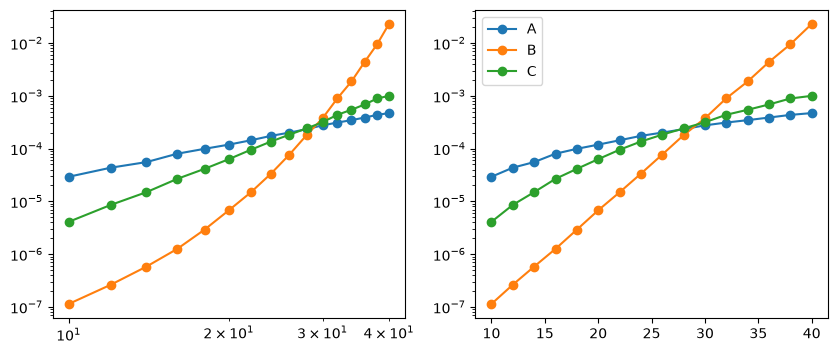

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].loglog(ns, t_A, "o-", label="A")
axes[0].loglog(ns, t_B, "o-", label="B")
axes[0].loglog(ns, t_C, "o-", label="C")
plt.legend()
axes[1].semilogy(ns, t_A, "o-", label="A")
axes[1].semilogy(ns, t_B, "o-", label="B")
axes[1].semilogy(ns, t_C, "o-", label="C")
plt.legend()

plt.show()


**Question:** which data sets look straight on which axes? Write down your guess for A, B and C: polynomial or exponential?

### Step 3: the split test

**Why?** In Step 2 you judged "straight or not" by eye. The split test does the same with numbers: if a model is right, its parameter ($a$ or $b$) is the **same** everywhere in the data, so fitting the **first half** and the **second half** separately gives (almost) the same value. If the model is wrong, the two halves give clearly **different** values.

Write a function `split_test(fit, ns, ts)`.

**Inputs**
- `fit`: one of your two fitting **functions** from Step 1, `fit_loglog` or `fit_semilogy`. Pass it by name, **without parentheses**: `split_test(fit_loglog, ns, t_A)`, not `split_test(fit_loglog(), ns, t_A)`. Inside `split_test`, call it like any function: `fit(some_ns, some_ts)`.
- `ns`, `ts`: the input sizes and the times (two arrays of the same length).

**Returns** a list of two numbers, `[first, second]`: `fit` applied to the first half of the data, and `fit` applied to the second half.

Example: `split_test(fit_loglog, ns, 4e-10 * ns**4)` gives `[4.0, 4.0]`, since $n^4$ has exponent $4$ on both halves.

<details><summary><b>Steps (open if you need them)</b></summary>

1. compute the middle index `h = len(ns) // 2` (here `ns` has 16 values, so `h = 8`);
2. the first half is `ns[:h]`, `ts[:h]` and the second half is `ns[h:]`, `ts[h:]`;
3. return `[fit(ns[:h], ts[:h]), fit(ns[h:], ts[h:])]`.

</details>

In [84]:
def split_test(fit, ns, ts):
    # Write your code here, then delete the line `pass` below.
    pass

In [85]:
# check: compare your results with the expected ones
r_semi = split_test(fit_semilogy, ns, 4e-10 * ns**4.0)
r_log = split_test(fit_loglog, ns, 4e-10 * ns**4.0)
if r_semi is None or r_log is None:
    print("split_test returned None: finish the function (and delete the line `pass`), then run this cell again.")
else:
    print("split_test(fit_semilogy, ns, 4e-10 * ns**4) =", np.round(r_semi, 3), "   (expected: [1.279 1.13 ]: drifts, wrong model)")
    print("split_test(fit_loglog,   ns, 4e-10 * ns**4) =", np.round(r_log, 3), "   (expected: [4. 4.]: agrees, right model)")

split_test returned None: finish the function (and delete the line `pass`), then run this cell again.


Now apply the test to the three data sets `t_A`, `t_B` and `t_C`. For **each** of them, print `split_test` with **both** fitting functions, so you get **six** results:

| data | polynomial model | exponential model |
|---|---|---|
| `t_A` | `split_test(fit_loglog, ns, t_A)` | `split_test(fit_semilogy, ns, t_A)` |
| `t_B` | `split_test(fit_loglog, ns, t_B)` | `split_test(fit_semilogy, ns, t_B)` |
| `t_C` | `split_test(fit_loglog, ns, t_C)` | `split_test(fit_semilogy, ns, t_C)` |

<details><summary><b>Hint</b></summary>

A loop avoids writing six lines:

```python
for name, ts in [("A", t_A), ("B", t_B), ("C", t_C)]:
    print(name, "loglog a:", split_test(fit_loglog, ns, ts), "  semilogy b:", split_test(fit_semilogy, ns, ts))
```

Wrap the results in `np.round(..., 3)` to make them easier to read.

</details>

In [86]:
# your code here: split_test with both fitting functions for t_A, t_B and t_C

**Questions:**
1. For each data set, which model agrees on both halves (up to a difference of order $10^{-2}$ or $10^{-1}$, because of the timing noise)? Give the Big-$O$ of A, B and C.

---
## Problem 2: where does it converge?

**Goal:** the iteration

$$x_{k+1} = g(x_k), \qquad g(x) = \frac{x^2 + 2}{3}$$

is one way to solve $x^2 - 3x + 2 = 0$. Find **where** it can converge, **which** starting points get there, and **how fast**.

**What you will see:** the equation has two solutions, but the iteration can only find one of them, and the slope $g'(x_\ast)$ tells you which one and how fast.

In [87]:
def g2(x):
    return (x**2 + 2) / 3

### Step 1: predict with pen and paper

1. Solve $g(x_\ast) = x_\ast$ to find the two **fixed points**.
2. With $g'(x) = 2x/3$, compute $g'$ at each fixed point. Which one **attracts**, which one **repels**?
3. For the attracting one, what rate $C$ do you predict?

*Your answers:*

- fixed points:
- $g'$ at each, attracting or repelling:
- predicted $C$:

### Step 2: try several starting points

Write code that:

1. for each starting point in `[0.0, 1.5, 1.9, 2.0, 2.1, 2.5]`, runs `iterate(g2, x0, 60)` and prints the starting point, how many values were computed, and the last value (if the values blow up, `iterate` stops early);
2. draws two cobweb plots side by side: `cobweb(g2, 1.9, 15, 0, 2.6, ax=axes[0])` and `cobweb(g2, 2.1, 8, 0, 2.6, ax=axes[1])`.

<details><summary><b>Hint</b></summary>

```python
for x0 in [0.0, 1.5, 1.9, 2.0, 2.1, 2.5]:
    xs = iterate(g2, x0, 60)
    print(x0, len(xs), xs[-1])
```

</details>

In [88]:
# your code here

In [89]:
# check: compare your results with the expected ones
print("iterate(g2, 1.9, 60)[-1]  =", iterate(g2, 1.9, 60)[-1], "   (expected: 1.00000000067..., creeping towards 1)")
print("iterate(g2, 2.0, 60)[-1]  =", iterate(g2, 2.0, 60)[-1], "   (expected: 2.0: a fixed point never moves)")
print("len(iterate(g2, 2.1, 60)) =", len(iterate(g2, 2.1, 60)), "   (expected: 15: it blew up past 1e8)")

iterate(g2, 1.9, 60)[-1]  = 1.0000000006704652    (expected: 1.00000000067..., creeping towards 1)
iterate(g2, 2.0, 60)[-1]  = 2.0    (expected: 2.0: a fixed point never moves)
len(iterate(g2, 2.1, 60)) = 15    (expected: 15: it blew up past 1e8)


**Questions:** which starting points (with $x_0 \ge 0$) end up at $1$? Why does $x_0 = 2.0$ stay put while $x_0 = 2.1$, which is very close, runs away? How do the two cobweb pictures show this?

### Step 3: measure the rate $C$

Write code that:

1. runs `iterate(g2, 0.0, 60)`, turns it into a NumPy array, and computes the errors $\epsilon_k = |x_k - 1|$ (call them `e2`);
2. prints the ratios $\epsilon_{k+1}/\epsilon_k$ for $k = 20, \ldots, 24$;
3. plots `e2` with `semilogy` against $k$.

<details><summary><b>Hint</b></summary>

`e2[21:26] / e2[20:25]` gives the five ratios at once.

</details>

In [90]:
# your code here: replace None by your array of errors |x_k - 1|
e2 = None

In [91]:
# check: compare your results with the expected ones
if e2 is None:
    print("e2 is still None: write the code in the cell above, then run this cell again.")
else:
    print("e2[21:26] / e2[20:25] =", np.round(e2[21:26] / e2[20:25], 4), "   (expected: about 0.6666 each)")

e2 is still None: write the code in the cell above, then run this cell again.


**Questions:**
1. Do the ratios match your predicted $C = |g'(1)|$? Is the `semilogy` plot a straight line? What type of convergence is this?

---
## Problem 3: how fast, and what if $x_\ast$ is unknown?

**Goal:** four sequences converge. Classify each one as sublinear, linear or superlinear, measure its order $q$, and then estimate the error **without** knowing the answer.

| sequence | limit $x_\ast$ |
|---|---|
| **e-seq:** $x_k = (1 + 1/k)^k$, $k = 1, 2, \ldots$ | $e$ |
| **slow:** $x_{k+1} = x_k - 0.035\,(x_k^2 - 2)$, $x_0 = 1$ | $\sqrt 2$ |
| **fast:** $x_{k+1} = x_k - 0.25\,(x_k^2 - 2)$, $x_0 = 1$ | $\sqrt 2$ |
| **Newton:** $x_{k+1} = \tfrac12(x_k + 2/x_k)$, $x_0 = 1$ | $\sqrt 2$ |

**What you will see:** the ratio $\epsilon_{k+1}/\epsilon_k$ tells the three types apart, the `loglog` plot of $\epsilon_{k+1}$ vs. $\epsilon_k$ gives the order, and the steps $\delta_k$ reveal the rate even when $x_\ast$ is unknown.

Run the cell below to compute the four error sequences (do not change it).

In [92]:
kk_e = np.arange(1, 61)
eps_e = np.abs((1 + 1 / kk_e)**kk_e - np.e)

g_slow = lambda x: x - 0.035 * (x**2 - 2)
g_fast = lambda x: x - 0.25 * (x**2 - 2)
g_newton = lambda x: (x + 2 / x) / 2

eps_slow = np.abs(np.array(iterate(g_slow, 1.0, 60)) - np.sqrt(2))
eps_fast = np.abs(np.array(iterate(g_fast, 1.0, 40)) - np.sqrt(2))
eps_newton = np.abs(np.array(iterate(g_newton, 1.0, 6)) - np.sqrt(2))

eps_fast = eps_fast[eps_fast > 1e-14]        # keep only errors above the floating point floor
eps_newton = eps_newton[eps_newton > 1e-14]

### Step 1: classify with the ratio $\epsilon_{k+1}/\epsilon_k$

Write a function `ratios(eps)`.

**Input:** `eps`, a NumPy array of errors $\epsilon_0, \epsilon_1, \ldots$

**Returns** the array of ratios $\epsilon_1/\epsilon_0,\ \epsilon_2/\epsilon_1,\ \ldots$

Then print `np.round(ratios(eps), 3)` for each of the four sequences and classify each sequence with the table from Section 4: does the ratio creep up to $1$, stay at a constant $C < 1$, or go to $0$?

<details><summary><b>Hint</b></summary>

One line: divide "all but the first" by "all but the last" (see the table of useful Python).

</details>

In [93]:
def ratios(eps):
    # Write your code here, then delete the line `pass` below.
    pass

In [94]:
# your code here: print the ratios of the four sequences

In [95]:
# check: compare your results with the expected ones
r_e, r_slow, r_fast, r_newton = ratios(eps_e), ratios(eps_slow), ratios(eps_fast), ratios(eps_newton)
if r_e is None or r_slow is None or r_fast is None or r_newton is None:
    print("ratios returned None: finish the function (and delete the line `pass`), then run this cell again.")
else:
    print("e-seq, a few ratios :", np.round(r_e[[0, 9, 29, 58]], 3), "   (expected: [0.652 0.916 0.969 0.984]: creeps up to 1)")
    print("slow, a few ratios  :", np.round(r_slow[[0, 9, 29, 58]], 3), "   (expected: [0.916 0.907 0.902 0.901]: constant, about 0.90)")
    print("fast, a few ratios  :", np.round(r_fast[[0, 9, 19]], 3), "   (expected: [0.396 0.293 0.293]: constant, about 0.29)")
    print("Newton, all ratios  :", r_newton, "   (expected: 0.21, 0.029, 0.00087, 7.5e-07: goes to 0)")

ratios returned None: finish the function (and delete the line `pass`), then run this cell again.


**Questions:**
1. Classify the four sequences. For the linear ones, what is $C$?
2. For slow and fast, $g'(x) = 1 - 2 \cdot 0.035\,x$ and $1 - 2 \cdot 0.25\,x$. Compute $|g'(\sqrt 2)|$ for each and compare with the ratios.

### Step 2: see it on the two plots

Make **one figure with two panels** side by side, `fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))`. **Each** of the four error arrays `eps_e`, `eps_slow`, `eps_fast`, `eps_newton` gets **one curve in each panel**:

| panel | what to plot for each `eps` | Python for one `eps` |
|---|---|---|
| left, `axes[0]` | the errors against $k$ on `semilogy` | `axes[0].semilogy(eps, "o-", ms=3, label=name)` |
| right, `axes[1]` | $\epsilon_{k+1}$ against $\epsilon_k$ on `loglog` | `axes[1].loglog(eps[:-1], eps[1:], "o-", ms=3, label=name)` |

In the right panel, also draw the dashed reference line $y = x$ once: `axes[1].loglog([1e-14, 1], [1e-14, 1], "k--", label="y = x")`. Label the axes and add a legend to both panels.

<details><summary><b>Steps (open if you need them)</b></summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name, eps in [("e-seq", eps_e), ("slow", eps_slow), ("fast", eps_fast), ("Newton", eps_newton)]:
    # left panel: one line for eps against k (semilogy)
    # right panel: one line for eps[1:] against eps[:-1] (loglog)
    ...
# right panel: the dashed line y = x
# axis labels: "k" and "error" on the left; "eps_k" and "eps_(k+1)" on the right
# legends on both panels, then plt.show()
```

</details>

In [96]:
# your code here: one figure, two panels, four curves in each panel

Now write `order_estimates(eps)`.

**Input:** `eps`, a NumPy array of errors.

**Returns** the array of estimates $q_k = \dfrac{\log(\epsilon_{k+1}/\epsilon_k)}{\log(\epsilon_k/\epsilon_{k-1})}$, one for each $k = 1, \ldots, \text{len(eps)} - 2$.

Then print `np.round(order_estimates(eps_fast), 3)` and `np.round(order_estimates(eps_newton), 3)`.

<details><summary><b>Steps (open if you need them)</b></summary>

1. `r = np.log(ratios(eps))` gives all the $\log(\epsilon_{k+1}/\epsilon_k)$;
2. return `r[1:] / r[:-1]`: each log-ratio divided by the one before it.

</details>

In [97]:
def order_estimates(eps):
    # Write your code here, then delete the line `pass` below.
    pass

In [98]:
# your code here: print order_estimates for eps_fast and eps_newton

In [99]:
# check: compare your results with the expected ones
if ratios(eps_newton) is None:
    print("ratios returned None: finish `ratios` in Step 1 first, then run this cell again.")
else:
    q_lin = order_estimates(0.5**np.arange(6))
    q_quad = order_estimates(10.0**(-(2.0**np.arange(5))))
    q_newton = order_estimates(eps_newton)
    q_fast = order_estimates(eps_fast)
    if q_lin is None or q_quad is None or q_newton is None or q_fast is None:
        print("order_estimates returned None: finish the function (and delete the line `pass`), then run this cell again.")
    else:
        print("test, linear    :", q_lin, "   (expected: [1. 1. 1. 1.])")
        print("test, quadratic :", q_quad, "   (expected: [2. 2. 2.])")
        print("Newton          :", np.round(q_newton, 3), "   (expected: [2.258 1.984 2.   ])")
        print("fast, last three:", np.round(q_fast[-5:-2], 3), "   (expected: about [1. 1. 1.])")

ratios returned None: finish `ratios` in Step 1 first, then run this cell again.


**Questions:**
1. On `semilogy`, which curve flattens, which are straight lines, which bends down? Does that match Step 1?
2. On the `loglog` plot, which points hug $y = x$, which run parallel below it, and which are steeper? Why is slow closer to $y = x$ than fast?
3. What order $q$ do you read off for fast and Newton? Why are the first $q_k$ less reliable than the last ones?

### Step 3: pretend you do not know $x_\ast$

For the **slow** sequence, forget that the answer is $\sqrt 2$. Write code that:

1. runs `xs_slow = np.array(iterate(g_slow, 1.0, 300))` and computes the steps `d_slow = np.abs(np.diff(xs_slow))` ($\delta_k = |x_{k+1} - x_k|$);
2. estimates $C$ **from the steps alone**: print `ratios(d_slow)[100]`;
3. computes the true errors `e_slow = np.abs(xs_slow - np.sqrt(2))` (for checking only) and plots `e_slow` and `d_slow` with `semilogy` on one figure, with a legend;
4. **stopping test:** finds the first $k$ with $\delta_k < 10^{-8}$ (`k_stop = np.argmax(d_slow < 1e-8)`) and prints the step `d_slow[k_stop]` and the true error there, `e_slow[k_stop + 1]`.

<details><summary><b>Hint</b></summary>

`np.argmax(d_slow < 1e-8)` gives the index of the first `True` in the array `d_slow < 1e-8`.

</details>

In [100]:
# your code here: replace each None
xs_slow = None     # 1. the iterates, as a NumPy array
d_slow = None      # 1. the steps delta_k
e_slow = None      # 3. the true errors (for checking only)
k_stop = None      # 4. the first k with delta_k < 1e-8

In [101]:
# check: compare your results with the expected ones
if d_slow is None or e_slow is None or k_stop is None:
    print("d_slow, e_slow or k_stop is still None: write the code in the cell above, then run this cell again.")
else:
    r_steps = ratios(d_slow)
    if r_steps is None:
        print("ratios returned None: finish `ratios` in Step 1 first, then run this cell again.")
    else:
        print("C from the steps:", round(float(r_steps[100]), 4), "   (expected: 0.901)")
        print("k_stop          :", k_stop, "   (expected: 148)")
        print("true error / step at the stop:", round(float(e_slow[k_stop + 1] / d_slow[k_stop]), 2), "   (expected: about 9.1)")

d_slow, e_slow or k_stop is still None: write the code in the cell above, then run this cell again.


**Questions:**
1. Are the two curves parallel? What does that mean for measuring $C$ (and $q$) without knowing $x_\ast$?
2. The iteration stopped because the step was below $10^{-8}$, but the true error is about **9 times** larger. Compare with $\frac{C}{1-C}$ for your $C$ from the steps. How could you choose the tolerance to get a true error below $10^{-8}$?
3. For the fast sequence ($C \approx 0.29$), would the error be larger or smaller than the step? Why?